In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama

In [30]:
llm = ChatOllama(
    model = "qwen2.5:1.5b",
    temperature = 0.7
)

In [31]:
response = llm.invoke("Hello")
print(response.content)

Hello! How can I assist you today?


In [32]:
# create a state 
class LLMState(TypedDict):
    question: str 
    answer: str 

In [33]:
def question_answer(state: LLMState):
    global llm
    response = llm.invoke(state['question'])
    state['answer'] = response.content
    return state 

In [35]:
# graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node("question_answer" , question_answer)

# add edges
graph.add_edge(START , "question_answer")
graph.add_edge("question_answer" , END)
workflow = graph.compile()

In [37]:
initial_state = {
    "question": "whats the capital of bangladesh?"
}
final_state = workflow.invoke(initial_state)
final_state

{'question': 'whats the capital of bangladesh?',
 'answer': 'The capital of Bangladesh is Dhaka.'}

In [38]:
class BlogState(TypedDict):
    topic: str 
    outline: str 
    blog: str

In [47]:
def create_outline(state: BlogState):
    global llm
    response = llm.invoke(
        f"""create a detailed outline on this topic: {state['topic']}
        so that we can make a blog by following this outline.Don't add any introductory lines"""
    )
    state['outline'] = response.content
    return state

In [48]:
def create_blog(state: BlogState):
    global llm
    response = llm.invoke(
        f"""create a detailed blog on this topic: {state['topic']} 
        by following this outline: \n{state['outline']}"""
    )
    state['blog'] = response.content
    return state

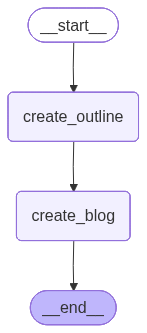

In [49]:
graph = StateGraph(BlogState)

# add nodes
graph.add_node("create_outline" , create_outline)
graph.add_node("create_blog" , create_blog)

# add edges
graph.add_edge(START , "create_outline")
graph.add_edge("create_outline" , "create_blog")
graph.add_edge("create_blog" , END)
blog_workflow = graph.compile()
blog_workflow

In [50]:
final_state = blog_workflow.invoke({
    "topic" : "Agentic AI"
})

In [51]:
final_state['topic']

'Agentic AI'

In [52]:
print(final_state['outline'])

Sure! Here's a detailed outline for an article about "Agentic AI":
I. Introduction A. Definition of Agentic AI B. Importance of Agentic AI in modern technology C. Brief history and development of Agentic AI D. Current state of Agentic AI research E. Potential future applications of Agentic AI
II. What is Agentic AI? A. Explanation of the term "agentic" in technology B. Overview of how Agentic AI works C. Comparison with other types of AI D. Importance of data-driven decision-making in Agentic AI
III. Benefits and Advantages of Agentic AI A. Improved efficiency and productivity B. Increased accuracy and precision C. Enhanced problem-solving capabilities D. Faster innovation and development E. Greater adaptability to changing environments F. Better customer engagement and satisfaction G. Reduced risk of errors and mistakes H. More sustainable solutions I. Lower cost and lower environmental impact
IV. Challenges and Limitations of Agentic AI A. Data quality and availability B. Ethical con

In [53]:
print(final_state['blog'])

### Introduction

Agentic Artificial Intelligence (AI) is a rapidly evolving field that aims to create intelligent systems capable of making decisions independently, guided by data-driven insights rather than predefined rules. This article will delve into the definition and importance of Agentic AI, explore its benefits and advantages, discuss potential challenges and limitations, examine future trends in this area, and conclude with recommendations for continued research and development.

### What is Agentic AI?

Agentic AI refers to a form of artificial intelligence where decision-making processes are driven by data rather than explicit instructions. This approach contrasts with traditional AI systems that rely on predefined rules or algorithms. Instead, it relies heavily on large datasets to learn patterns and make informed decisions based on these learned insights.

### Benefits and Advantages of Agentic AI

**Improved Efficiency and Productivity:**
Agentic AI can automate routine 